In [1]:
# Please run all of these imports:

import time
import_start = time.perf_counter()
import os, sys, random
import numpy as np
import torch

from fock_utils import utils_orca_out, fock_targets
from train_utils import loss, utils_compute, splittrainer
from dataset_utils import get_loader
from dataset_utils.ASEDataset import ASEAtomsData
from dataset_utils.nablaDFT_dataset_utils import HamiltonianDatabase

# Models
from equiformer.network import SO2Net
from equiformer.SO3 import CoefficientMappingModule
from esen.esen_new import eSEN_Backbone, Fock_Irreps_Head, Linear_Force_Head, Convolution_Force_Head, Gated_Force_Head     # NO EDGES: .esen_noedges
from e3nn.o3 import Irreps

import_end = time.perf_counter()
print("Time to do imports: ", import_end - import_start)

# Fix random seeds for distributed model initialization
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Time to do imports:  30.252195810200647


# Setting Up and Running eSEN-fock (temporary name): A Guide
#### By: Manasa

In this tutorial, we will go through the process of training a fock-matrix prediction network on water molecules. Specifically, we will use the QM7-water dataset, which contains the Kohn-Sham Hamiltonian matrices for 5000 water molecules wiggling along an MD trajectory. There are three parts:

1. Data setup - The supervised learning process requires [inputs] the set of nodes + edges in each atomic structure and [outputs] the direct sums of irreducible representations (irreps) corresponding to the orbital blocks of the Hamiltonian for each node and edge.

2. Network setup and training - The model itself is a modified architecture based on eSEN, which incorporates learnable edge embeddings and anti-symmetry of interactions under exchange. The latter is handled in both (edges) the message passing blocks and (nodes) the output head.

3. Postprocessing - The trained network will output a direct sum of irreps for each node and edge in the input graph. These quantities must be post-processed to reconstruct the Hamiltonian matrix prediction. 



In [82]:
# -----------------------------------------------------------------
# Full set of config parameters and options
# -----------------------------------------------------------------

# --> Data and output settings:
dbpath = 'fock_datasets/QM7/schnorb_hamiltonian_water.db'                   # Path to the database
dataset_name = 'QM7'                                                        # Name of the dataset ('QM7', 'nablaDFT', 'omol' are currently supported)           
output_folder = 'outputs_tutorial'                                          # Name of the folder in which we will save the results
shuffle_database = False                # For actual runs, the database should be shuffled first

restart_backbone = False                # restart the backbone model from a checkpoint (it will look inside output_folder for 'backbone.pt')
restart_head = False                    # restart the head model from a checkpoint (it will look inside output_folder for 'head.pt')
restart_optimizer = False               # restart the optimizer from a checkpoint (it will load the optimizer from 'backbone.pt')

# --> Model settings:
l_embedding_dim = 128                   # number of sphere channels used to expand each irrep embedding in the network
num_distance_basis = 128                # number of gaussian basis functions used to expand the edge distance 
hidden_dim = l_embedding_dim            # hidden dimension which the messages are projected to within the convolution layers
num_mp_layers = 3                       # number of message passing layers (eSCN convolutions) in the network

# --> Training settings:
num_val = 500                           # Number of validation structures
num_train = 500                         # Number of training structures 
num_epochs = 2000                     # Number of epochs to train the model 
batch_size = 10                         # batch size for training
rcut_orbitals = 6.0                     # connectivity cutoff (orbital blocks > 2xrcut_orbitals will be ignored)
rcut_gaussian = 10.0                    # distance to which we will have gaussian basis functions
gaussian_width = 1.0                    # width of gaussians used to expand edge distance

# --> Enable/disable symmetry under exchange
reduce_edge = True                      # train with only edge orbital blocks for edge i,j where i<j (other edges are the antisymetric version of these)
reduce_node = True                      # inter-orbital forward/backward interactions are enforced to be exactly antisymmetric under exchange
reduce_node_intra = True                # intra-orbital forward/backward interactions are are enforced to be exactly antisymmetric under exchange

train_backbone = True                   # train the backbone model (if False, the backbone will be frozen) 
train_head = True                       # train the head model (if False, the head will be frozen)

dtype = torch.float64
lr_init = 5e-4
patience = 500                          # if using ReduceLROnPlateau scheduler
threshold = 1e-8                        # if using ReduceLROnPlateau scheduler

loss_target = 'fock_matrix'                               # What labels to use for the loss ('fock_matrix' or 'forces')
train_loss_fxn = loss.combined_padded_loss                # combined_padded_loss: rmse+mae
loss_scheduler = loss.MonotonicDecreaseScheduler          # This is a custom scheduler that increases/decreases the lr according to the change in the loss
backbone_checkpoint = 'backbone.pt'                       
head_checkpoint = 'head.pt'
include_edges = False if loss_target == 'forces' else True 



In [4]:
# --------------------------------------------
# Initialize compute environment 
# --------------------------------------------

# This is a python notebook tutorial, so we will not use distributed training. We will use 1 GPU.
os.environ["MASTER_ADDR"] = os.uname()[1]
os.environ["MASTER_PORT"] = "29500"
rank = 0
world_size = 1

compute_start = time.perf_counter()
device = utils_compute.setup_env(rank, world_size)
compute_end = time.perf_counter()
print("Time to setup distributed environment: ", compute_end - compute_start)


Initializing distributed process group... 
Time to setup distributed environment:  0.08496174984611571


[W Utils.hpp:135] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function getCvarInt)


In [8]:
# -----------------------------------------------------------------
# Load the database
# -----------------------------------------------------------------

if not os.path.exists(dbpath):
    raise FileNotFoundError(f"Database file not found at {dbpath}!")
torch.set_default_dtype(dtype)
database = ASEAtomsData(dbpath)

if shuffle_database:
    print("Shuffling database...")
    indices = list(range(len(database)))
    random.shuffle(indices)
    database = [database[i] for i in indices]

# --> Make the output folder 
if rank == 0 and not os.path.exists(output_folder):
    os.makedirs(output_folder)

if rank == 0:
    print(f"Dataset: {dataset_name}, writing results to {output_folder}", flush=True)
    print(f"Dataset - Num molecules used for training: {num_train}", flush=True)
    print(f"Dataset - Num molecules used for validation: {num_val}", flush=True)
    print(f"Dataset - Edge cutoff distance for orbital blocks: {2*rcut_orbitals}", flush=True)
    print(f"Dataset - Edge cutoff distance for gaussian basis: {rcut_gaussian}", flush=True)
    print(f"Model - Num of Message Passing layers: {num_mp_layers}", flush=True)
    print(f"Model - Embedding dimension: {l_embedding_dim}", flush=True)
    print(f"Model - # Distance basis functions: {num_distance_basis}", flush=True)
    print(f"Model - Edge reduction: {reduce_edge}")
    print(f"Model - Node reduction - interorbital: {reduce_node}")
    print(f"Model - Node reduction - intraorbital: {reduce_node_intra}")
    print(f"Training - Loss target: {loss_target}", flush=True)
    print(f"Training - Loss function: {train_loss_fxn}", flush=True)
    print(f"Training - Initial learning rate: {lr_init}", flush=True)



Dataset: QM7, writing results to outputs_tutorial
Dataset - Num molecules used for training: 500
Dataset - Num molecules used for validation: 500
Dataset - Edge cutoff distance for orbital blocks: 12.0
Dataset - Edge cutoff distance for gaussian basis: 10.0
Model - Num of Message Passing layers: 3
Model - Embedding dimension: 128
Model - # Distance basis functions: 128
Model - Edge reduction: True
Model - Node reduction - interorbital: True
Model - Node reduction - intraorbital: True
Training - Loss target: fock_matrix
Training - Loss function: <function combined_padded_loss at 0x7a69519d4c20>
Training - Initial learning rate: 0.0005


In [10]:
# -----------------------------------------------------------------
# 1. Preparing the datasets for train/val/test
# -----------------------------------------------------------------

data_load_start = time.perf_counter()

# If we were running in a distributed environment, this would take care of even data distribution
train_start_mol, train_end_mol, train_local_num_mol = utils_compute.split_indices(rank, world_size, num_train)
val_start_mol, val_end_mol, val_local_num_mol  = utils_compute.split_indices(rank, world_size, num_val)
test_start_mol, test_end_mol, test_local_num_mol = utils_compute.split_indices(rank, world_size, num_test)

val_start_mol += num_train           
val_end_mol += num_train
test_start_mol += num_train+num_val
test_end_mol += num_train+num_val

train_loader, required_irreps, basis_transformation, orbital_basis = get_loader.get_loader(database, train_start_mol, train_end_mol, dataset_name, rcut_orbitals, batch_size, dtype=dtype, reflection_symmetry=reduce_edge)
val_loader, _, _, _ = get_loader.get_loader(database, val_start_mol, val_end_mol, dataset_name, rcut_orbitals, batch_size, dtype=dtype, reflection_symmetry=reduce_edge)
print("Size of train loader: ", len(train_loader))
print("Size of val loader: ", len(val_loader))

data_load_end = time.perf_counter()
print("Time to load dataset: ", data_load_end - data_load_start)

Processing 500 structures between 1 GPUs
IMPORTANT NOTE: Ignoring 0 indices to make the distribution even!
Rank 0 does indices 0 to 500
Processing 500 structures between 1 GPUs
IMPORTANT NOTE: Ignoring 0 indices to make the distribution even!
Rank 0 does indices 0 to 500
Processing 4500 structures between 1 GPUs
IMPORTANT NOTE: Ignoring 0 indices to make the distribution even!
Rank 0 does indices 0 to 4500
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing symmetric edges!
Note: Reducing

In [67]:
# -----------------------------------------------------------------
# Let's look at the data corresponding to the first H2O molecule to 
# see what the inputs (atomic structure) and labels look like
# -----------------------------------------------------------------
%matplotlib inline

import matplotlib.pyplot as plt
from ase import Atoms
from ase.visualize import view
from mpl_toolkits.mplot3d import Axes3D

train_start_mol=0
train_end_mol=1
sample_loader, required_irreps, basis_transformation, orbital_basis = get_loader.get_loader(database, 
                                                                                            train_start_mol, 
                                                                                            train_end_mol, 
                                                                                            dataset_name, 
                                                                                            rcut_orbitals, 
                                                                                            batch_size, 
                                                                                            dtype=dtype, 
                                                                                            reflection_symmetry=reduce_edge)
# --> Examine the molecule:
for mol0 in sample_loader:
    mol_ase_atom = mol0.fock_target_object[0].atoms
    hamiltonian_matrix = mol0.fock_target_object[0].fock_matrix.cpu()
    node_labels = mol0.node_y
    edge_labels = mol0.y

print("Atomic structure of the molecule:")
view(mol_ase_atom, viewer='x3d')


Note: Reducing symmetric edges!
required irreps:  1x0e+1x0e+1x0e+1x1e+1x1e+1x2e+1x0e+1x0e+1x0e+1x1e+1x1e+1x2e+1x0e+1x0e+1x0e+1x1e+1x1e+1x2e+1x1e+1x1e+1x1e+1x0e+1x1e+1x2e+1x0e+1x1e+1x2e+1x1e+1x2e+1x3e+1x1e+1x1e+1x1e+1x0e+1x1e+1x2e+1x0e+1x1e+1x2e+1x1e+1x2e+1x3e+1x2e+1x2e+1x2e+1x1e+1x2e+1x3e+1x1e+1x2e+1x3e+1x0e+1x1e+1x2e+1x3e+1x4e
Atomic structure of the molecule:


/opt/hpcaas/.mounts/fs-0565f60d669b6a2d3/home/manasakani/ocp-modeling-dev/manasakani/dataset_utils/get_loader.py:78: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  energies=torch.tensor(energy, dtype=dtype),
/opt/hpcaas/.mounts/fs-0565f60d669b6a2d3/home/manasakani/ocp-modeling-dev/manasakani/dataset_utils/get_loader.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  forces=torch.tensor(forces, dtype=dtype),                                      # Hartree/Angstrom


Hamiltonian matrix of the molecule:


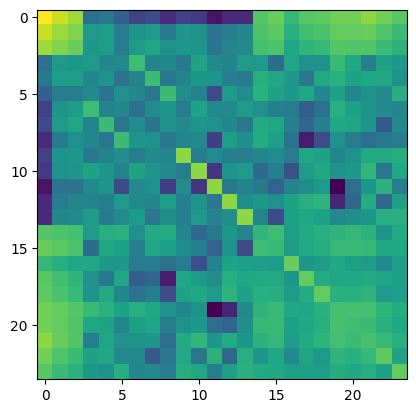

In [68]:
print("Hamiltonian matrix of the molecule:")
plt.imshow(np.log(np.abs(hamiltonian_matrix)))
plt.show()

Node targets for O, H, H (direct sum of irreps reshaped to a square matrix):


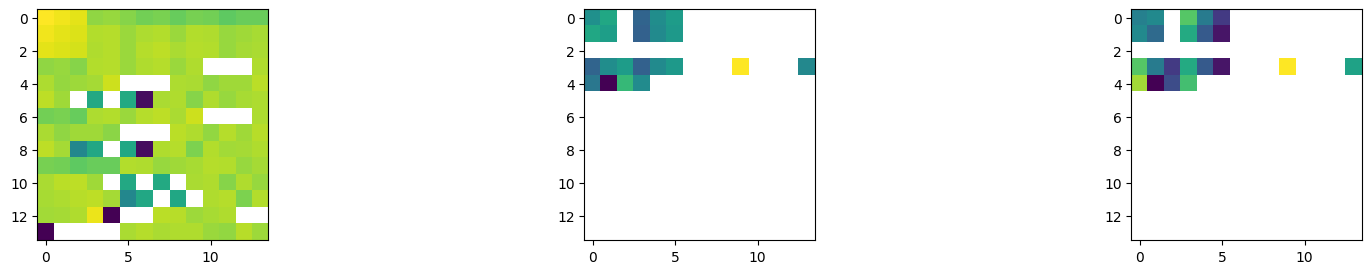

In [69]:
import warnings
warnings.filterwarnings("ignore", message="divide by zero encountered in log")

fig, axs = plt.subplots(1, 3, figsize=(20, 3))

print("Node targets for O, H, H (direct sum of irreps reshaped to a square matrix):")
for i, node in enumerate(node_labels):
    axs[i].imshow(np.log(np.abs(node.reshape(14, 14).cpu())))
plt.show()

Edge targets for O1-H1, O1-H2, H1-H2, H1-O, H2-O, H2-H1 (direct sum of irreps reshaped to a square matrix):
Note: If reduce_edge=True, half of these will be empty


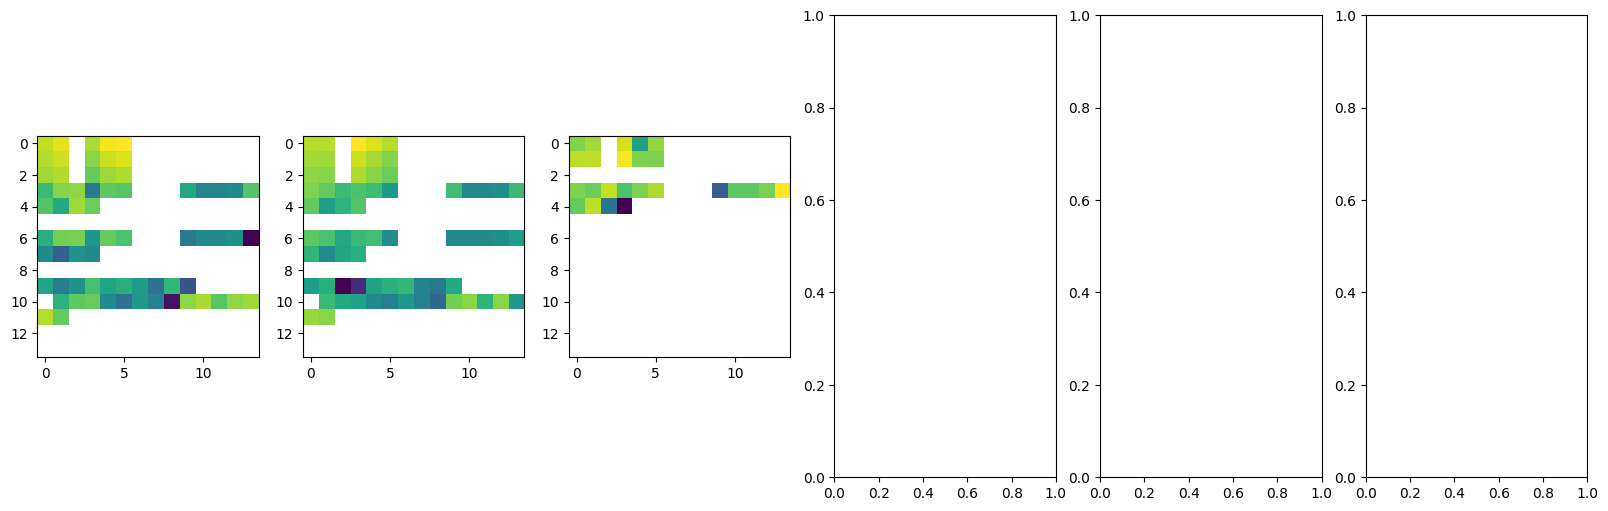

In [70]:
import warnings
warnings.filterwarnings("ignore", message="divide by zero encountered in log")

fig, axs = plt.subplots(1, 6, figsize=(20, 6))

print("Edge targets for O1-H1, O1-H2, H1-H2, H1-O, H2-O, H2-H1 (direct sum of irreps reshaped to a square matrix):")
print("Note: If reduce_edge=True, half of these will be empty")
for i, edge in enumerate(edge_labels):
    axs[i].imshow(np.log(np.abs(edge.reshape(14, 14).cpu())))
plt.show()

Oxygen atom node:
(1) original orbital block
(2) ... after padding and reorganization to match the shape of the required irreps
(3) ... then transformed into the coupled space, and reshaped into a square matrix
(4) ... and then reverse-transformed into the uncoupled space


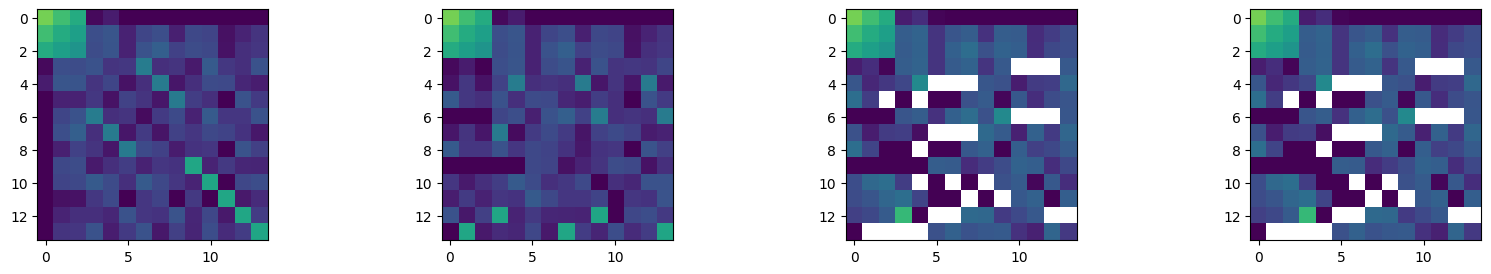

In [76]:
# -----------------------------------------------------------------
# Let's check that the basis transformation works as expected
# -----------------------------------------------------------------

original_orbital_block = hamiltonian_matrix[0:14, 0:14]
a_node_coupled = node_labels[0]
a_node_uncoupled = basis_transformation.get_H(a_node_coupled.unsqueeze(0))

a_node_coupled_again = basis_transformation.get_H(a_node_coupled.unsqueeze(0))

print("Oxygen atom node:")
print("(1) original orbital block")
print("(2) ... after padding and reorganization to match the shape of the required irreps")
print("(3) ... then transformed into the coupled space, and reshaped into a square matrix")
print("(4) ... and then reverse-transformed into the uncoupled space")

fig, axs = plt.subplots(1, 4, figsize=(20, 3))
axs[0].imshow(np.log(np.abs(original_orbital_block.cpu())), vmin=-5.0, vmax=5.0)
axs[1].imshow(np.log(np.abs(a_node_uncoupled.reshape(14, 14).cpu())), vmin=-5.0, vmax=5.0)
axs[2].imshow(np.log(np.abs(a_node_coupled.reshape(14, 14).cpu())), vmin=-5.0, vmax=5.0)
axs[3].imshow(np.log(np.abs(a_node_uncoupled_again.reshape(14, 14).cpu())), vmin=-5.0, vmax=5.0)

plt.show()




In [81]:
# -----------------------------------------------------------------
# 2. Setting up the eSEN-Fock Network
# -----------------------------------------------------------------

output_irreps = required_irreps
node_target = 'node_y'
edge_target = 'y'
irreps_in = Irreps([(l_embedding_dim, (l, 1)) for l in range(required_irreps.lmax + 1)]) 

backbone = eSEN_Backbone(
                            required_irreps,
                            sphere_channels=l_embedding_dim,
                            hidden_channels=hidden_dim,
                            lmax=required_irreps.lmax,
                            mmax=required_irreps.lmax,
                            use_pbc=False,
                            cutoff=rcut_gaussian,
                            edge_channels=l_embedding_dim,
                            num_layers=num_mp_layers,
                            act_type='gate',
                            mlp_type = 'spectral',
                            num_distance_basis=num_distance_basis,
                            gaussian_width=gaussian_width,
                            include_edges=include_edges
                        )

head = Fock_Irreps_Head(irreps_in=irreps_in, 
                        irreps_out=output_irreps, 
                        lmax=required_irreps.lmax, 
                        sphere_channels=l_embedding_dim,
                        reduce_node=reduce_node,
                        reduce_node_intra=reduce_node_intra,
                        orbital_basis=orbital_basis)


backbone = backbone.to(device)
head = head.to(device)

if train_backbone and train_head:
    optimizer = torch.optim.Adam(list(backbone.parameters()) + list(head.parameters()), lr=lr_init)

elif train_head:                            # freeze backbone model
    for param in backbone.parameters(): 
        param.requires_grad = False
    optimizer = torch.optim.Adam(head.parameters(), lr=lr_init)

elif train_backbone:                        # freeze output head
    for param in head.parameters():     
        param.requires_grad = False
    optimizer = torch.optim.Adam(backbone.parameters(), lr=lr_init)

else:
    print("Running evaluation")

print("Number of parameters in backbone: ", sum(p.numel() for p in backbone.parameters()))
print("Number of parameters in output head: ", sum(p.numel() for p in head.parameters()))

if restart_backbone:
    restart_file = output_folder + '/' + backbone_checkpoint
    print("Restarting backbone model from :", restart_file)
    checkpoint = torch.load(restart_file)
    state_dict = checkpoint['model_state_dict']
    
    # Get rid of module prefix if saved with DDP
    new_state_dict = {}
    for key, value in state_dict.items():
        new_key = key.replace('module.', '')  
        new_state_dict[new_key] = value
    backbone.load_state_dict(new_state_dict)

if restart_head:
    restart_file = output_folder + '/' + head_checkpoint
    print("Restarting output head model from :", restart_file)
    checkpoint = torch.load(restart_file)
    state_dict = checkpoint['model_state_dict']

    if restart_optimizer:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    # Get rid of module prefix if saved with DDP
    new_state_dict = {}
    for key, value in state_dict.items():
        new_key = key.replace('module.', '')  
        new_state_dict[new_key] = value
    head.load_state_dict(new_state_dict)
    

Number of parameters in backbone:  33958528
Number of parameters in output head:  93056


In [ ]:
# -----------------------------------------------------------------
# Training the backbone+head of the model
# -----------------------------------------------------------------

scheduler = loss_scheduler(optimizer)

trainer = splittrainer.SplitTrainer(backbone=backbone, 
                                    head=head,
                                    head_irreps=output_irreps,
                                    run_name='water_jun8',
                                    save_frequency=100)

trainer.train(num_epochs, 
                train_loss_fxn, 
                optimizer,
                scheduler, 
                device,
                train_loader=train_loader,
                loss_target_string=loss_target,
                node_target_name=node_target, 
                edge_target_name=edge_target,
                output_folder=output_folder,
                val_loader=val_loader,
                train_backbone=train_backbone,
                train_head=train_head,
                basis_transform=basis_transformation)


Using MonotonicDecreaseScheduler for loss.


edge_loss,█▁▁▁
edge_val_loss,█▁▂▅
learning_rate,██▄▁
node_loss,█▁▁▁
node_val_loss,█▁▃▄
edge_loss,0.01378
edge_val_loss,0.01615
learning_rate,0.00049
node_loss,0.02411
node_val_loss,0.02005


Disabling torch amp
Loss Targets: node_y, y


[rank0]:[W Utils.hpp:108] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function getCvarString)
[rank0]:[W Utils.hpp:108] Warning: Environment variable NCCL_ASYNC_ERROR_HANDLING is deprecated; use TORCH_NCCL_ASYNC_ERROR_HANDLING instead (function getCvarString)


Epoch 1, Train Loss: [node] 0.15935644586720646 [edge] 0.11141061975858017
Epoch 1, Val Loss: [node] 0.02564723648799351 [edge] 0.016645933677080133
Current learning rate:  0.0005
Time per epoch:  21.21294532297179


/opt/hpcaas/.mounts/fs-0565f60d669b6a2d3/home/manasakani/ocp-modeling-dev/manasakani/train_utils/splittrainer.py:256: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_loss_node_tensor = torch.tensor(val_loss_node, device=device)
/opt/hpcaas/.mounts/fs-0565f60d669b6a2d3/home/manasakani/ocp-modeling-dev/manasakani/train_utils/splittrainer.py:257: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_loss_edge_tensor = torch.tensor(val_loss_edge, device=device)


Epoch 2, Train Loss: [node] 0.03348889719229208 [edge] 0.017407639626419745
Epoch 2, Val Loss: [node] 0.025368133869279306 [edge] 0.013622761264565764
Current learning rate:  0.0005
Time per epoch:  14.342980314977467
Epoch 3, Train Loss: [node] 0.022853256321913467 [edge] 0.013007804576593366
Epoch 3, Val Loss: [node] 0.016413632573603124 [edge] 0.00924054845087365
Current learning rate:  0.0005
Time per epoch:  14.164030368905514
Epoch 4, Train Loss: [node] 0.02060875660282617 [edge] 0.013584762738759672
Epoch 4, Val Loss: [node] 0.016413657351331906 [edge] 0.01795519347175934
Current learning rate:  0.000495
Time per epoch:  14.393572739092633
Epoch 5, Train Loss: [node] 0.01766658214857104 [edge] 0.010440503185553104
Epoch 5, Val Loss: [node] 0.011704841175666576 [edge] 0.007763703799048032
Current learning rate:  0.000495
Time per epoch:  14.132615199079737
Epoch 6, Train Loss: [node] 0.016438732010660956 [edge] 0.010466055649993596
Epoch 6, Val Loss: [node] 0.013293800628703185 [